In [2]:
import csv
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv('advanced_ecommerce_analytics.csv')
pd.set_option('display.max_columns', None)
print(df.head(4))
print(df.shape)
print(df.duplicated().sum())  #no duplication in rows
print(df.T.duplicated().sum())    #no duplication in columns
print(df.describe())
print(df.isna().sum())  #no missing values


    order_id        date customer_id  age  gender             city  \
0  ORD010000  2023-02-06   CUST02160   50    Male            Luxor   
1  ORD010001  2023-05-13   CUST01941   63  Female            Tanta   
2  ORD010002  2023-12-01   CUST02824   51  Female            Sohag   
3  ORD010003  2022-01-13   CUST00372   42  Female  Sharm El Sheikh   

        region  income     category    subcategory  price  quantity  \
0  Upper Egypt    5374       Health  Personal Care    678         8   
1        Delta    7235       Health       Pharmacy    482         8   
2  Upper Egypt    4565  Electronics         Gaming   6753         1   
3      Red Sea    9278       Health    Supplements    361         6   

   discount_percent  final_amount payment_method customer_segment  \
0                 0       5424.00  Bank Transfer           Budget   
1                 0      -3856.00    Credit Card          Regular   
2                14       5807.58    Credit Card           Budget   
3                

**case 1**

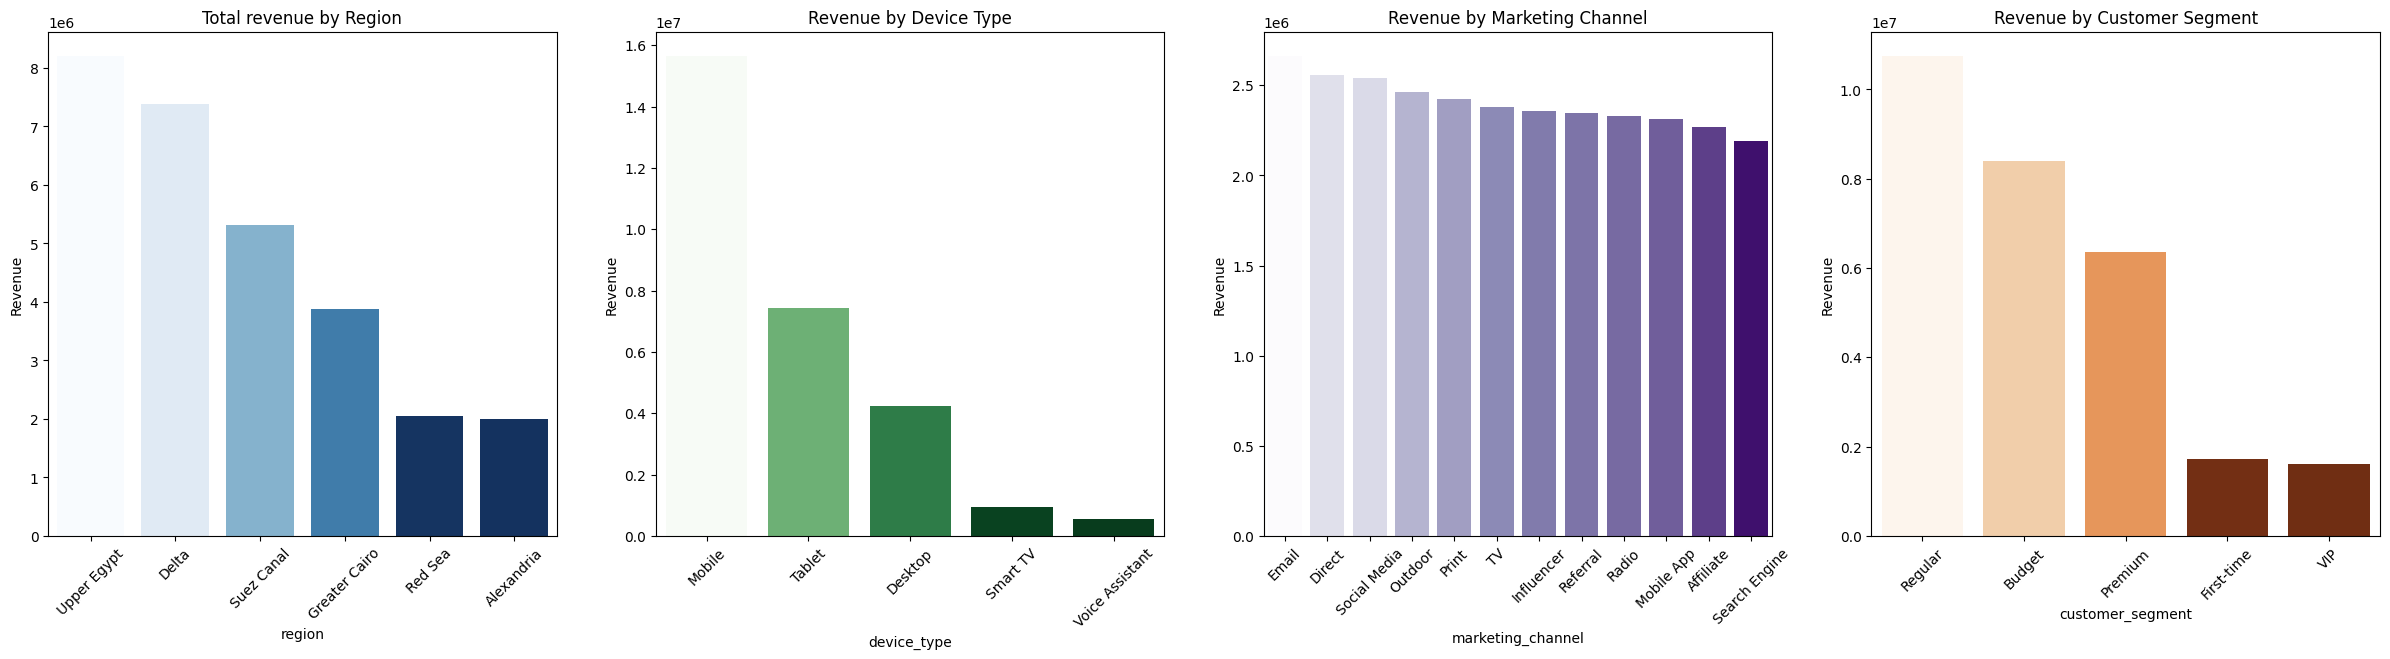

In [3]:
#analyse the revenue by region,device,marketing channel and customer segment
region_revenue = df.groupby('region')['final_amount'].sum().sort_values(ascending=False)
device_revenue = df.groupby('device_type')['final_amount'].sum().sort_values(ascending=False)
channel_revenue = df.groupby('marketing_channel')['final_amount'].sum().sort_values(ascending=False)
customer_segment_rev = df.groupby('customer_segment')['final_amount'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 4, figsize=(24, 6))

sns.barplot(x=region_revenue.index, y=region_revenue.values, ax=axes[0], palette='Blues_r', hue=region_revenue.values,legend=False)
axes[0].set_title("Total revenue by Region")
axes[0].set_ylabel("Revenue")

sns.barplot(x=device_revenue.index, y=device_revenue.values, ax=axes[1], palette='Greens_r', hue=device_revenue.values, legend=False)
axes[1].set_title("Revenue by Device Type")
axes[1].set_ylabel("Revenue")

sns.barplot(x=channel_revenue.index, y=channel_revenue.values, ax=axes[2], palette='Purples_r', hue=channel_revenue.values, legend=False)
axes[2].set_title("Revenue by Marketing Channel")
axes[2].set_ylabel("Revenue")

sns.barplot(x=customer_segment_rev.index, y=customer_segment_rev.values, ax=axes[3], palette='Oranges_r', hue=customer_segment_rev.values, legend=False)
axes[3].set_title("Revenue by Customer Segment")
axes[3].set_ylabel("Revenue")

plt.tight_layout()
for ax in axes:
    ax.tick_params(axis='x', rotation=45)
plt.show()


upper egypt has the heighest revenue and mobile shoping is most that brings revenue

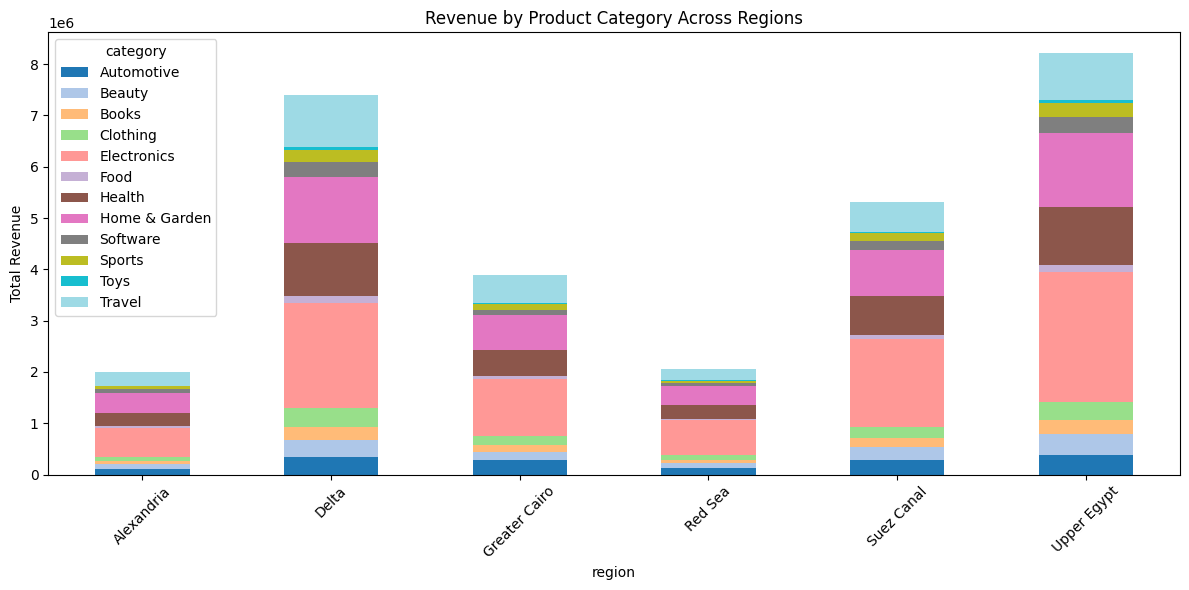

In [ ]:
#analysis of revenue bu catigories across regions
region_category = df.groupby(['region', 'category'])['final_amount'].sum().unstack().fillna(0)
region_category.plot(kind='bar', stacked=True, figsize=(12,6), colormap='tab20')
plt.title("Revenue by Product Category Across Regions")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

upper egypt purchases alotof electronics which is the highest source of revenue

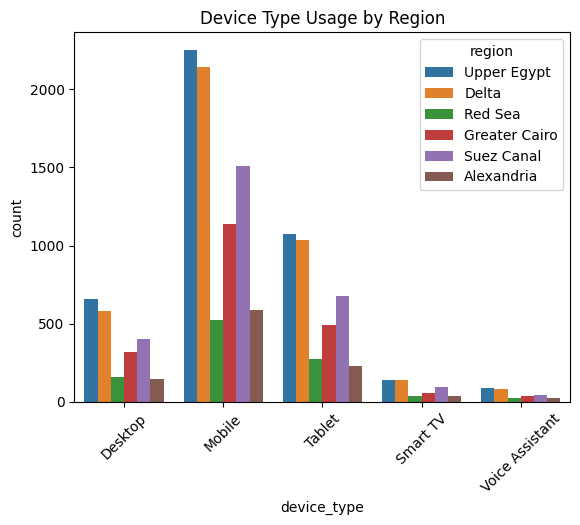

In [26]:
#analyse the device used across regions
sns.countplot(data=df, x='device_type', hue='region')
plt.title("Device Type Usage by Region")
plt.xticks(rotation=45)
plt.show()

alex has the lowest revenue becuse it does not use mobile as much as the rest of regions

/tmp/ipykernel_2641/3304526606.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=season_rev.index, y=season_rev.values, ax=axes[1], palette='Set2')


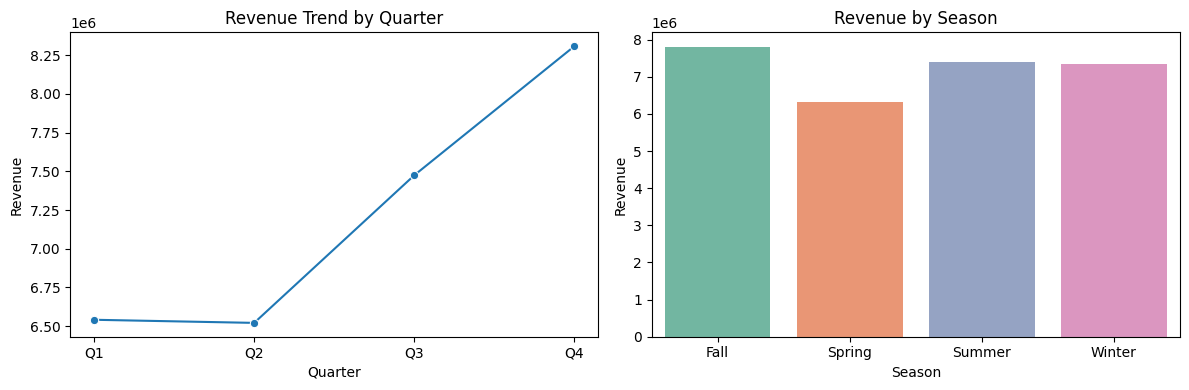

In [ ]:
#analysis of revenue bu quarter and season
quarter_rev = df.groupby('quarter')['final_amount'].sum().sort_index()
season_rev = df.groupby('season')['final_amount'].sum().sort_index()


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.lineplot(x=quarter_rev.index, y=quarter_rev.values, ax=axes[0], marker='o')
axes[0].set_title("Revenue Trend by Quarter")
axes[0].set_xlabel("Quarter")
axes[0].set_ylabel("Revenue")
sns.barplot(x=season_rev.index, y=season_rev.values, ax=axes[1], palette='Set2')
axes[1].set_title("Revenue by Season")
axes[1].set_xlabel("Season")
axes[1].set_ylabel("Revenue")

plt.tight_layout()
plt.show()

q3 qnd q4 are the most in revenue and fall is the produces the most revenue in seasons

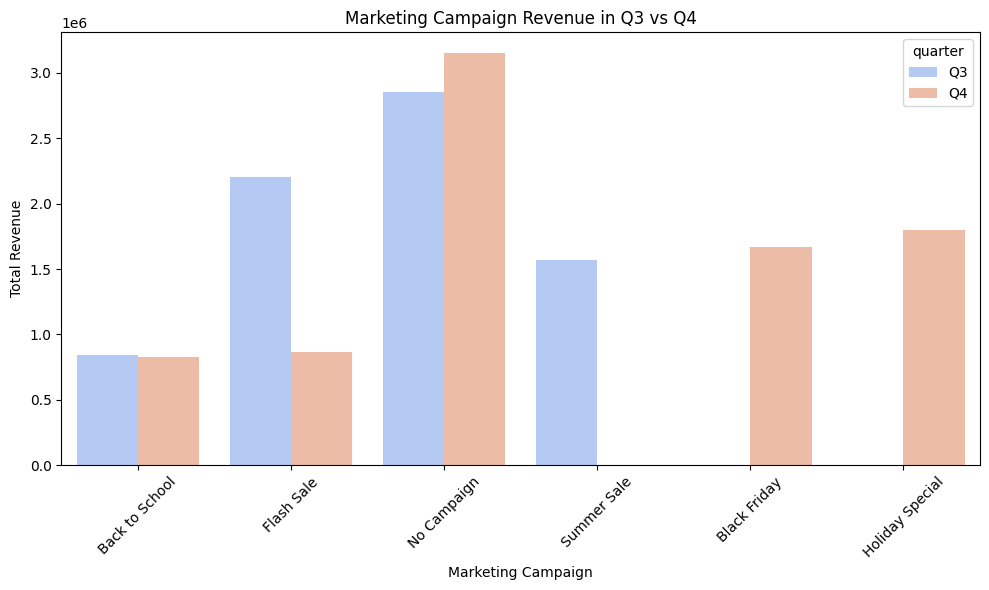

In [ ]:
#nalyse campaigns in q1 and q3 to fine why they produce the most revenue
q3_q4_df = df[df['quarter'].isin(['Q3', 'Q4'])]
campaign_revenue = (
    q3_q4_df.groupby(['quarter', 'marketing_campaign'])['final_amount']
    .sum()
    .reset_index()
)
plt.figure(figsize=(10, 6))
sns.barplot(data=campaign_revenue, x='marketing_campaign', y='final_amount', hue='quarter', palette='coolwarm')

plt.title("Marketing Campaign Revenue in Q3 vs Q4")   
plt.xlabel("Marketing Campaign")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Q3,Q4 have the highest revenue becuse of campaighnes like summer, black friday,...

**case 2**

            final_amount  satisfaction_rating
age_groups                                   
<25          2003.944509             3.876062
25–40        2374.310543             3.888923
41–60        1664.476359             3.925775
60+          1638.797286             3.954056


/tmp/ipykernel_2641/3895198647.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_states.index, y=age_states['final_amount'], ax=axes[0], palette='coolwarm')
/tmp/ipykernel_2641/3895198647.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_states.index, y=age_states['satisfaction_rating'], ax=axes[1], palette='viridis')


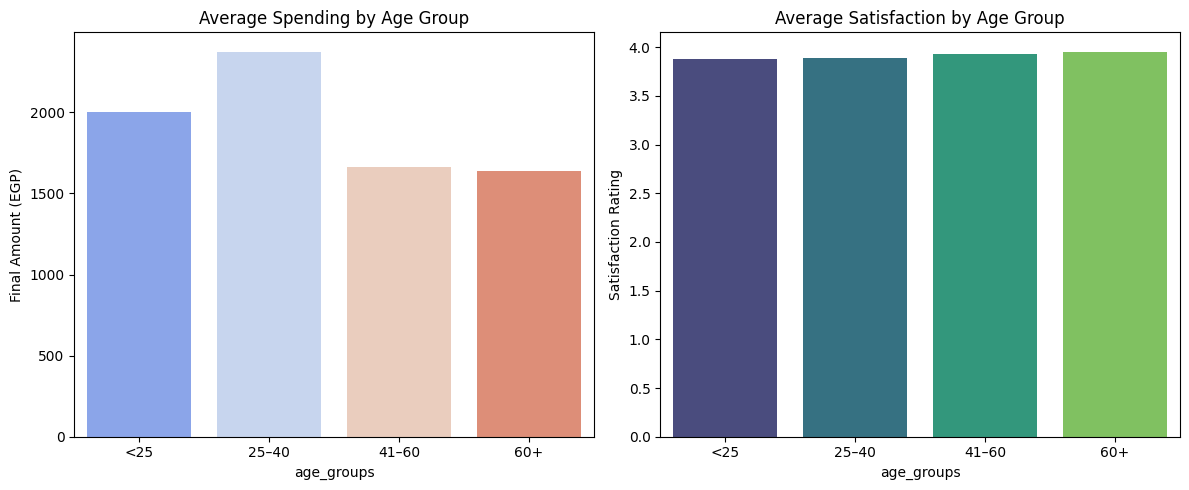

In [29]:
bins = [0 , 24, 40,60,100]
labels = ['<25', '25–40', '41–60', '60+']
df['age_groups'] = pd.cut(df['age'], bins=bins, labels=labels, right = True)  #dividing the age to groups of ranges

age_states = df.groupby('age_groups')[['final_amount','satisfaction_rating']].mean()
print(age_states)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(x=age_states.index, y=age_states['final_amount'], ax=axes[0], palette='coolwarm')
axes[0].set_title("Average Spending by Age Group")
axes[0].set_ylabel("Final Amount (EGP)")

sns.barplot(x=age_states.index, y=age_states['satisfaction_rating'], ax=axes[1], palette='viridis')
axes[1].set_title("Average Satisfaction by Age Group")
axes[1].set_ylabel("Satisfaction Rating")

plt.tight_layout()
plt.show()

ages from 25-40 has the hieghst spending and 60+ group have the heighest satisfaction

/tmp/ipykernel_2641/221640027.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=income_by_age_group.index, y=income_by_age_group.values, palette='coolwarm')


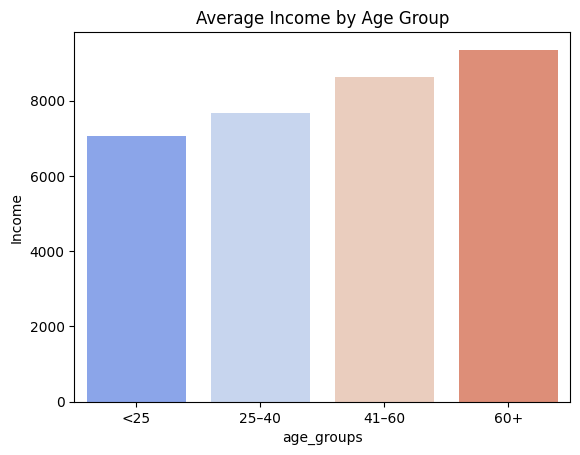

In [ ]:
#analysing the age group ay their income to figure out why 25-40 has the highest spending
income_by_age_group = df.groupby('age_groups')['income'].mean()
sns.barplot(x=income_by_age_group.index, y=income_by_age_group.values, palette='coolwarm')
plt.title("Average Income by Age Group")
plt.ylabel("Income")
plt.show()

60+ actually turned out to have the highest income not 25-40

/tmp/ipykernel_2641/235496538.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=revenue_by_category_60.values, y=revenue_by_category_60.index, palette='Greens_r')


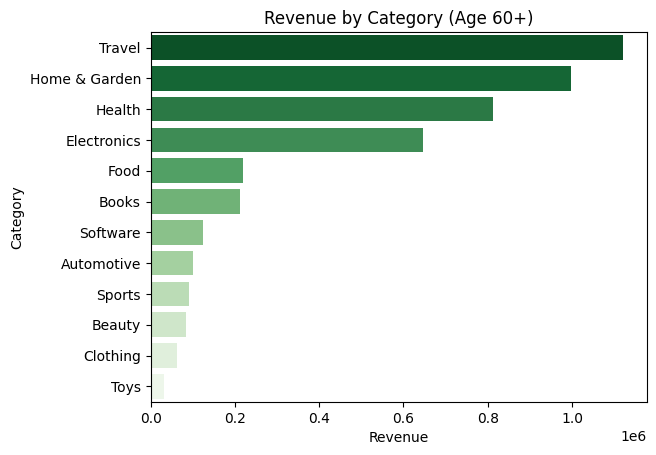

In [33]:
#analysing the 60+ according to the revenue comeing from the categories they mostly buy
age60_df = df[df['age_groups'] == '60+']
revenue_by_category_60 = age60_df.groupby('category')['final_amount'].sum().sort_values(ascending=False)

sns.barplot(x=revenue_by_category_60.values, y=revenue_by_category_60.index, palette='Greens_r')
plt.title("Revenue by Category (Age 60+)")
plt.xlabel("Revenue")
plt.ylabel("Category")
plt.show()

turns out travel is teh most category they purchase

/tmp/ipykernel_2641/2414420164.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_satisfaction.values, y=category_satisfaction.index, palette='Greens_r')


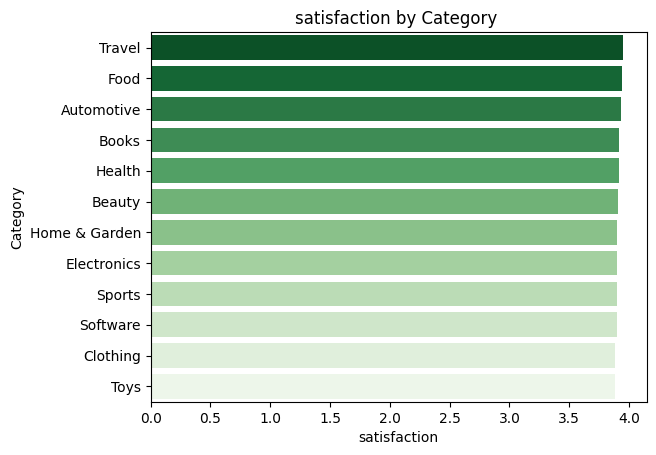

In [34]:
#analysing the satisfaction by category inorder to findout why 60+ has the heghest satisfaction rate
category_satisfaction = df.groupby('category')['satisfaction_rating'].mean().sort_values(ascending=False)
sns.barplot(x=category_satisfaction.values, y=category_satisfaction.index, palette='Greens_r')
plt.title("satisfaction by Category ")
plt.xlabel("satisfaction")
plt.ylabel("Category")
plt.show()

as expected travel is the heighest category that has satisfaction rate in that business and the old people purchse that category the most (probably going to travel after retiring ) that explains why the old people have the heighst satisfaction rate

/tmp/ipykernel_2641/1565829744.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=revenue_by_category_25_40.values, y=revenue_by_category_25_40.index, palette='Greens_r')


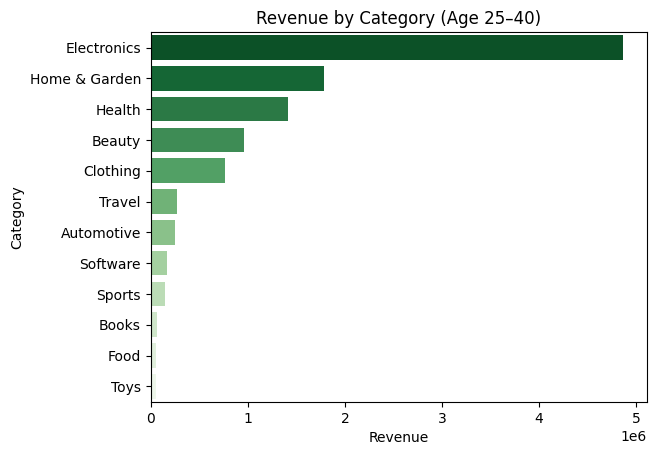

In [35]:
#analysing the 25-40 age groub by the revenue that come from the categories they purchase
age25_40_df = df[df['age_groups'] == '25–40']
revenue_by_category_25_40 = age25_40_df.groupby('category')['final_amount'].sum().sort_values(ascending=False)

sns.barplot(x=revenue_by_category_25_40.values, y=revenue_by_category_25_40.index, palette='Greens_r')
plt.title("Revenue by Category (Age 25–40)")
plt.xlabel("Revenue")
plt.ylabel("Category")
plt.show()  

electronics are the most categories they purchase 

/tmp/ipykernel_2641/28124056.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_revenue.values, y=category_revenue.index, palette='Greens_r')


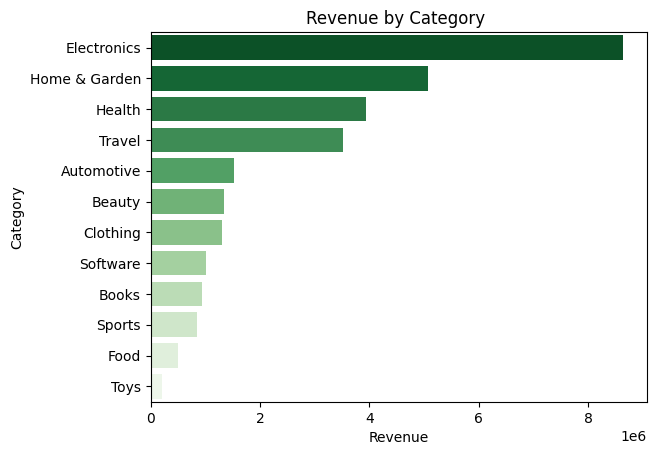

In [36]:
#seeing whivh categories produce the most revenue
category_revenue = df.groupby('category')['final_amount'].sum().sort_values(ascending=False)
sns.barplot(x=category_revenue.values, y=category_revenue.index, palette='Greens_r')
plt.title("Revenue by Category ")
plt.xlabel("Revenue")
plt.ylabel("Category")
plt.show()

as ecpected electronics brings the most revenue, which explains why the age group from 25-40 has the heighest spending as electronics is the  most category they buy (probably becuse they need it in their work and daily life in general)

**case 3**

/tmp/ipykernel_2641/552861168.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_clv.index, y=segment_clv.values, ax=axes[0], palette="Blues_r")
/tmp/ipykernel_2641/552861168.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=device_clv.index, y=device_clv.values, ax=axes[1], palette="Greens_r")
/tmp/ipykernel_2641/552861168.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=acquisition_clv.index, y=acquisition_clv.values, ax=axes[2], palette="Purples_r")
/tmp/ipykernel_2641/552861168.py:18: UserWarning: FixedFormatter sho

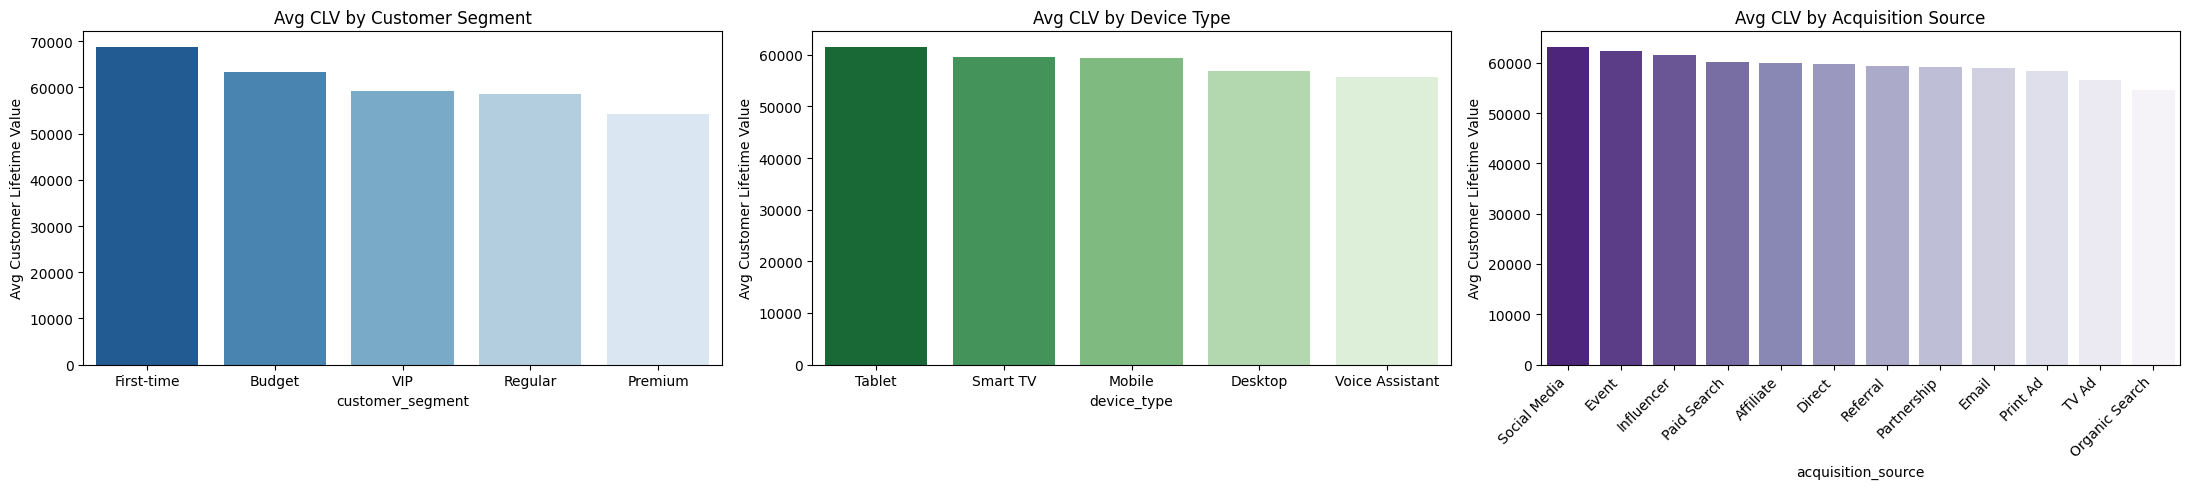

In [ ]:
#analysing the customer lifetime value by the customer segment, the device they use and the acuisition source
segment_clv = df.groupby('customer_segment')['customer_lifetime_value'].mean().sort_values(ascending=False)
device_clv = df.groupby('device_type')['customer_lifetime_value'].mean().sort_values(ascending=False)
acquisition_clv = df.groupby('acquisition_source')['customer_lifetime_value'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(22, 5))

sns.barplot(x=segment_clv.index, y=segment_clv.values, ax=axes[0], palette="Blues_r")
axes[0].set_title("Avg CLV by Customer Segment")
axes[0].set_ylabel("Avg Customer Lifetime Value")

sns.barplot(x=device_clv.index, y=device_clv.values, ax=axes[1], palette="Greens_r")
axes[1].set_title("Avg CLV by Device Type")
axes[1].set_ylabel("Avg Customer Lifetime Value")

sns.barplot(x=acquisition_clv.index, y=acquisition_clv.values, ax=axes[2], palette="Purples_r")
axes[2].set_title("Avg CLV by Acquisition Source")
axes[2].set_ylabel("Avg Customer Lifetime Value")
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

Fisrt time customers are the type of customer with expected heighst profit

/tmp/ipykernel_2641/2833450552.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=C_segment_revenue.values, y=C_segment_revenue.index, palette='Greens_r')


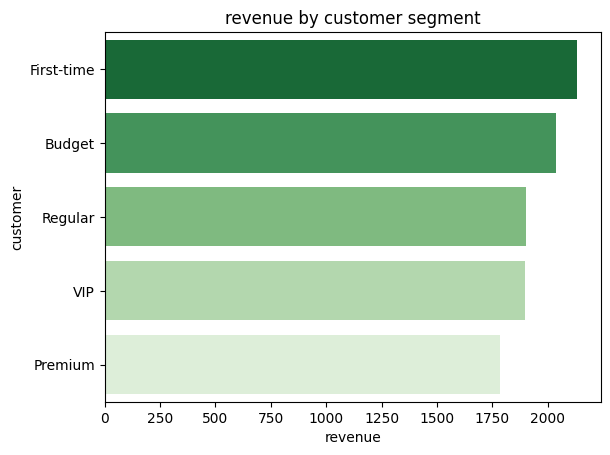

In [38]:
#analysing the customer segment by the revenue they get
C_segment_revenue = df.groupby('customer_segment')['final_amount'].mean().sort_values(ascending=False)
sns.barplot(x=C_segment_revenue.values, y=C_segment_revenue.index, palette='Greens_r')
plt.title("revenue by customer segment")
plt.xlabel("revenue")
plt.ylabel("customer")
plt.show()

as expected first time customers bring the heighset revenue that's why they are expected to bring the heighest profit (the heighest customer life time value)

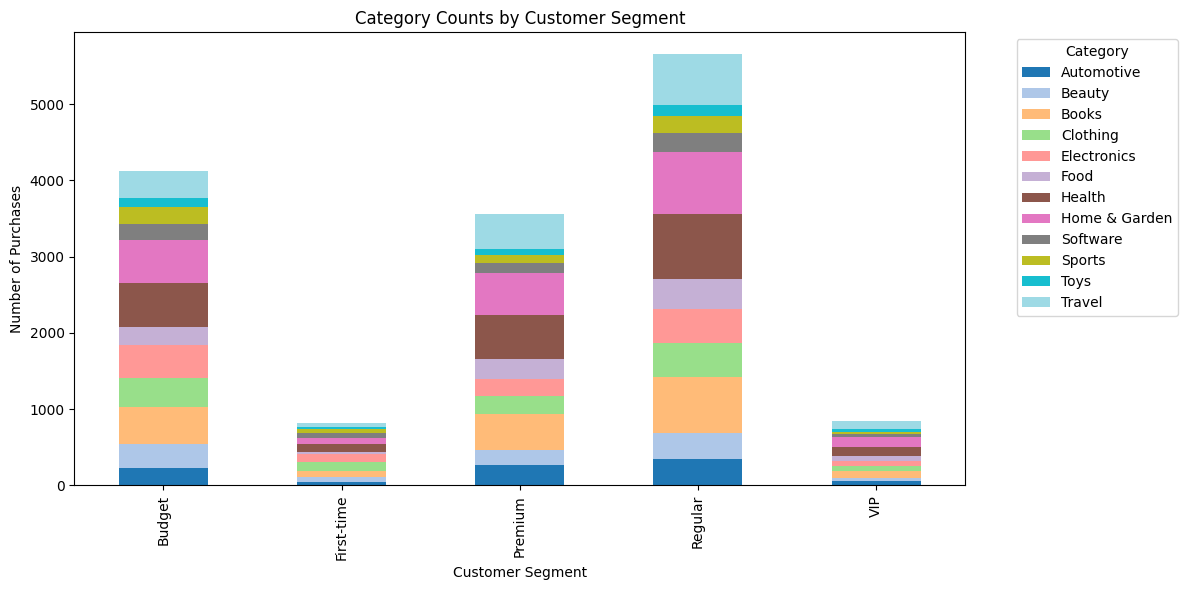

In [39]:
#analysing the customer segment by the total categories they purchase to fine out why first time customers bring the heighst revenue 
segment_category_counts = df.groupby(['customer_segment', 'category']).size().unstack().fillna(0)

segment_category_counts.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab20')
plt.title('Category Counts by Customer Segment')
plt.ylabel('Number of Purchases')
plt.xlabel('Customer Segment')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

first time customers are not the heighst in purchase which does not help in identifying why they bring the most revenue

/tmp/ipykernel_2641/1208540125.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_proportions.index, y=segment_proportions.values, palette='Set2')


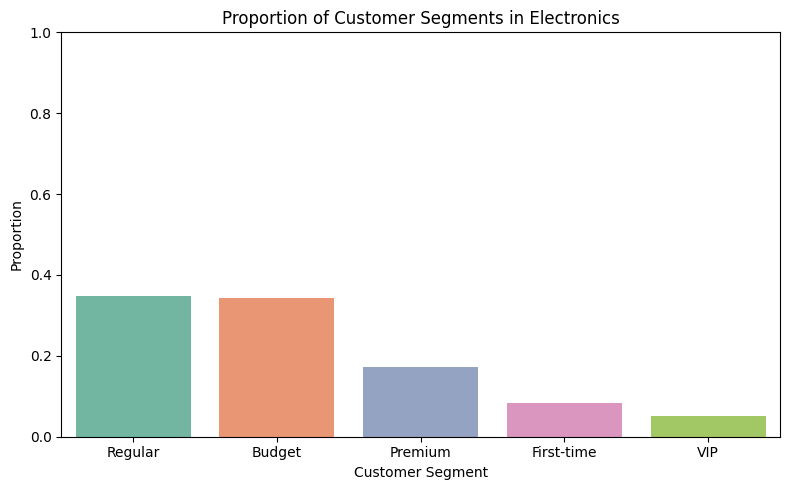

In [40]:
#anaysing the customer segment by count of ourchasing electronucs
high_value_category = df[df['category'].isin(['Electronics'])]
segment_proportions=high_value_category['customer_segment'].value_counts(normalize=True)

plt.figure(figsize=(8, 5))
sns.barplot(x=segment_proportions.index, y=segment_proportions.values, palette='Set2')
plt.title('Proportion of Customer Segments in Electronics')
plt.ylabel('Proportion')
plt.xlabel('Customer Segment')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

fisrt time customers is not the heighst in purchasing electronics too...which does not help in identifying why they bring the most revenue

/tmp/ipykernel_2641/1626502291.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette="pastel")


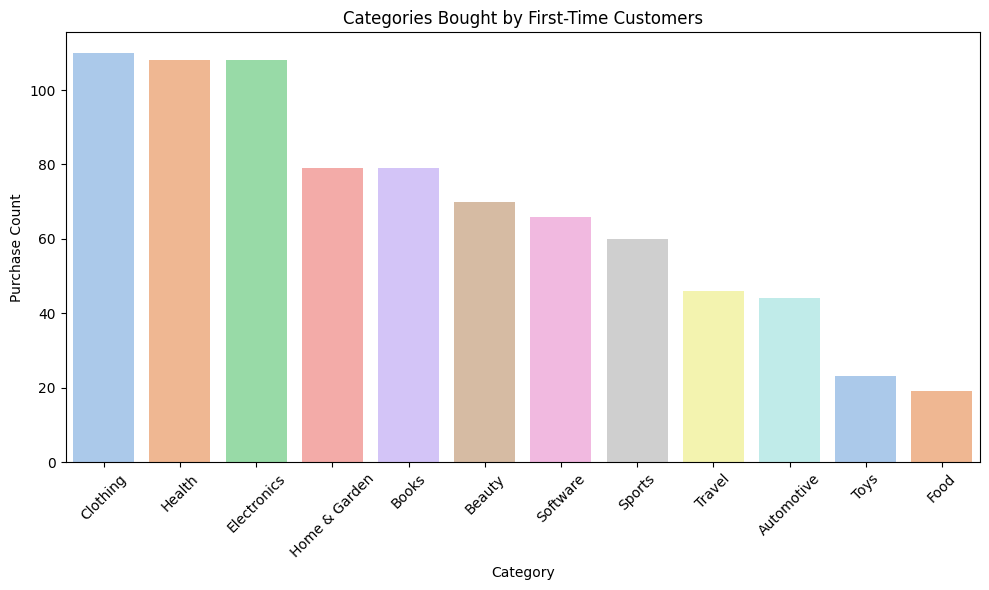

In [41]:
#anaysing first time customers by the most category they purchase
first_time_customers = df[df['customer_segment'] == 'First-time']
category_counts = first_time_customers['category'].value_counts()
plt.figure(figsize=(10, 6))
sns.barplot(x=category_counts.index, y=category_counts.values, palette="pastel")
plt.title("Categories Bought by First-Time Customers")
plt.xlabel("Category")
plt.ylabel("Purchase Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

clothing is the most category bought by first time customers which too does not explain wht they bring the most revenue

In [43]:
print(first_time_customers['customer_id'].count())

812


first time customers represent 812 out of total 1500...which is more that 50% of the total customers which explains why the bring the most revenue

**case 4**

/tmp/ipykernel_2641/4240342532.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=campaign_stats.index, x='Avg Revenue', data=campaign_stats, ax=axes[0], palette='Blues_r')
/tmp/ipykernel_2641/4240342532.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=campaign_stats.index, x='Avg Satisfaction', data=campaign_stats, ax=axes[1], palette='Greens_r')
/tmp/ipykernel_2641/4240342532.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=campaign_stats.index, x='Return Rate', data=campaign_stats, ax=axes[2], palette='Reds')


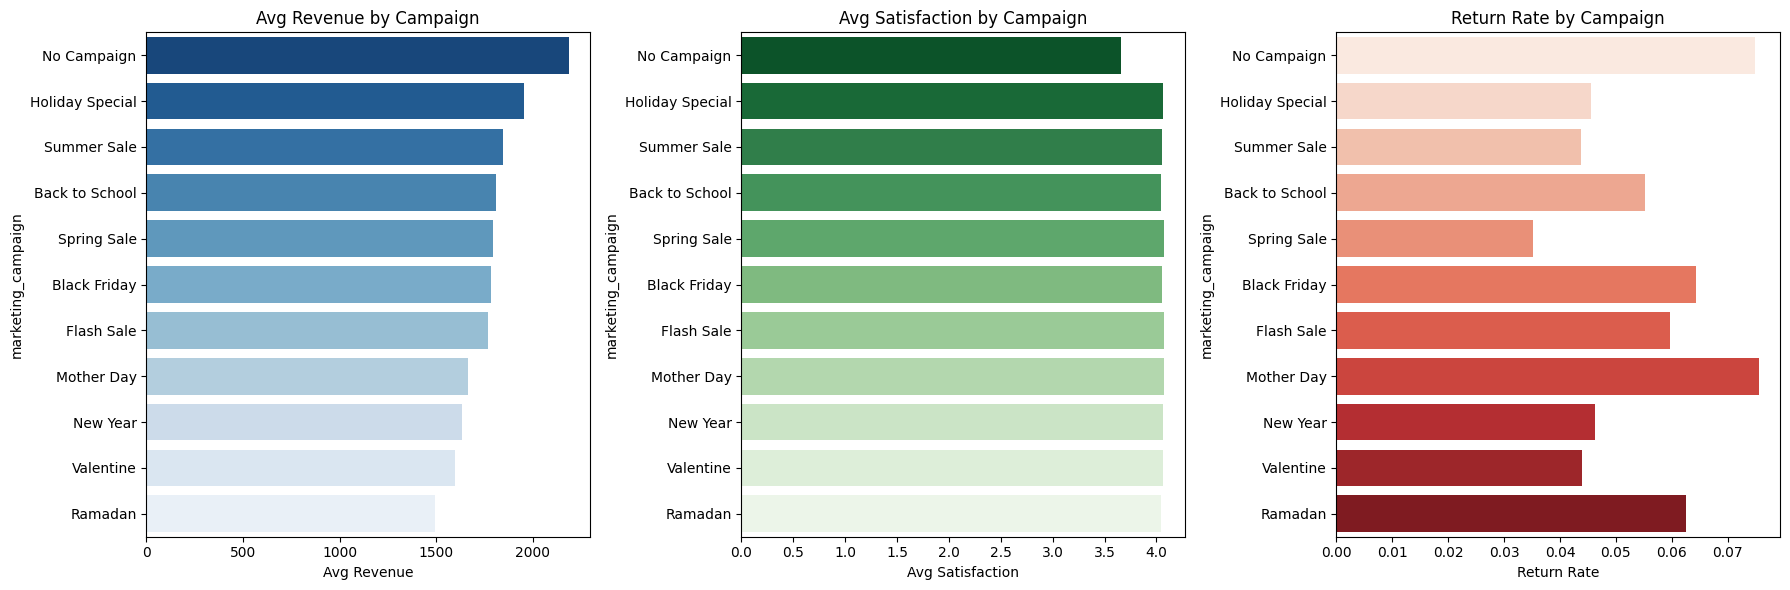

In [32]:
campaign_stats = df.groupby('marketing_campaign').agg({
    'final_amount': 'mean',
    'satisfaction_rating': 'mean',
    'returned': 'mean'  # mean of boolean gets us the per. 
}).rename(columns={
    'final_amount': 'Avg Revenue',
    'satisfaction_rating': 'Avg Satisfaction',
    'returned': 'Return Rate'
}).sort_values(by='Avg Revenue', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.barplot(y=campaign_stats.index, x='Avg Revenue', data=campaign_stats, ax=axes[0], palette='Blues_r')
axes[0].set_title('Avg Revenue by Campaign')

sns.barplot(y=campaign_stats.index, x='Avg Satisfaction', data=campaign_stats, ax=axes[1], palette='Greens_r')
axes[1].set_title('Avg Satisfaction by Campaign')

sns.barplot(y=campaign_stats.index, x='Return Rate', data=campaign_stats, ax=axes[2], palette='Reds')
axes[2].set_title('Return Rate by Campaign')

plt.tight_layout()
plt.show()

the most returned purchases are at mother day

/tmp/ipykernel_2641/2526439547.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette="Set2")


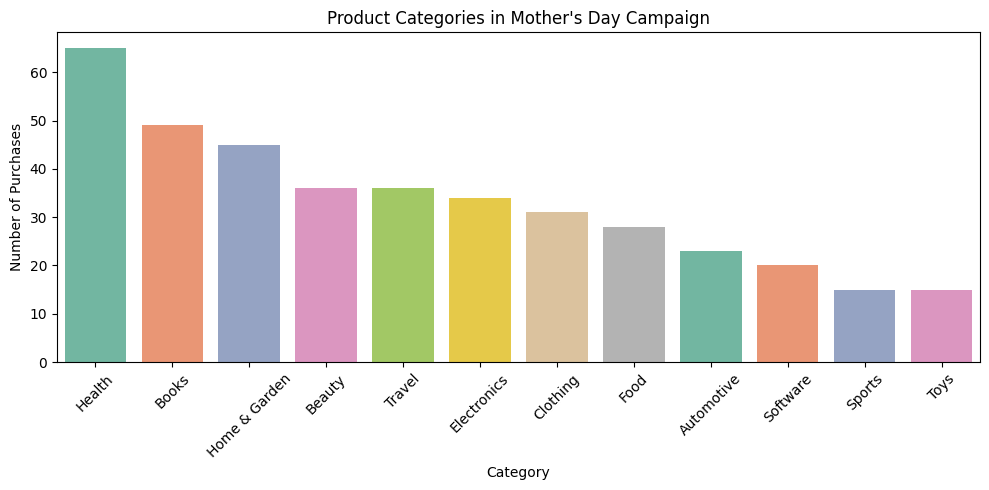

['No Campaign' 'Holiday Special' 'New Year' 'Flash Sale' 'Black Friday'
 'Ramadan' 'Mother Day' 'Back to School' 'Spring Sale' 'Valentine'
 'Summer Sale']


In [5]:
md_df = df[df['marketing_campaign'] == 'Mother Day']

category_counts = md_df['category'].value_counts()

plt.figure(figsize=(10,5))
sns.barplot(x=category_counts.index, y=category_counts.values, palette="Set2")
plt.title("Product Categories in Mother's Day Campaign")
plt.ylabel("Number of Purchases")
plt.xlabel("Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print(df['marketing_campaign'].unique())

/tmp/ipykernel_2641/3230722302.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=returned_counts.index, y=returned_counts.values, palette='coolwarm')


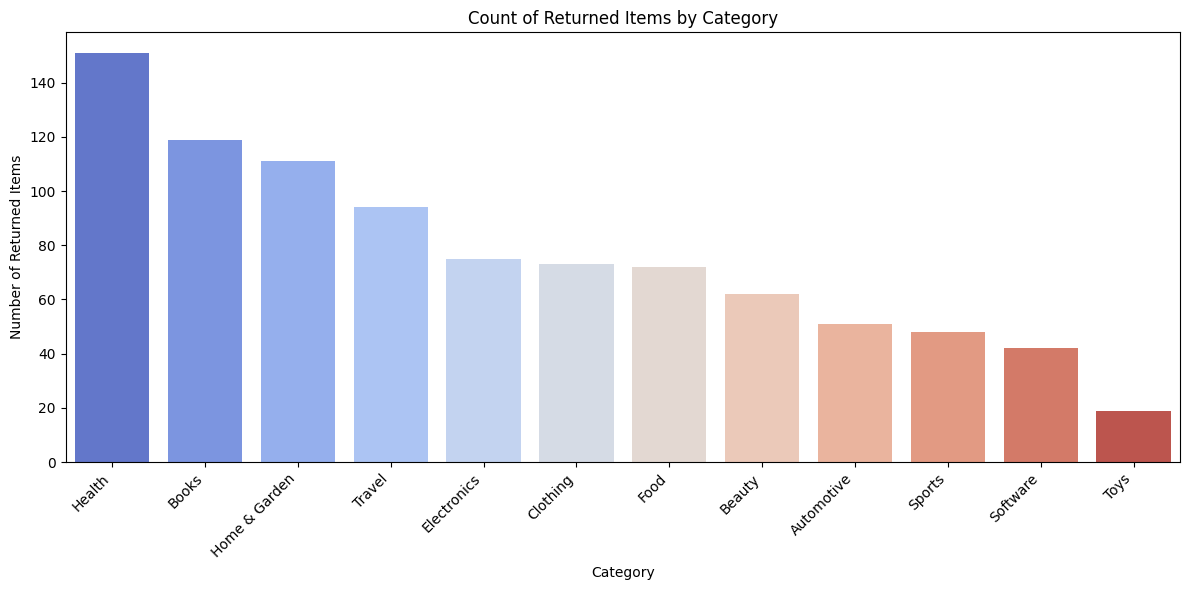

In [6]:
#analyse the return counts by category :
returned_df = df[df['returned'] == 1]
returned_counts = returned_df['category'].value_counts().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x=returned_counts.index, y=returned_counts.values, palette='coolwarm')
plt.title('Count of Returned Items by Category')
plt.xlabel('Category')
plt.ylabel('Number of Returned Items')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

the most returned category is health category

***case 5****

In [7]:
grouped_categories= df.groupby(['category', 'subcategory']).agg({
    'quantity': 'sum',
    'final_amount': 'sum'
}).reset_index().rename(columns={
    'quantity': 'total_quantity',
    'final_amount': 'total_revenue'
})

/tmp/ipykernel_2641/4270927973.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_revenue, x='subcategory', y='total_revenue', ax=axes[0], palette='Blues_r')
/tmp/ipykernel_2641/4270927973.py:10: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_2641/4270927973.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_quantity, x='subcategory', y='total_quantity', ax=axes[1], palette='Greens_r')
/tmp/ipykernel_2641/4270927973.py:15: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[1].set_xticklabels(axes[1].get_xticklabels(), r

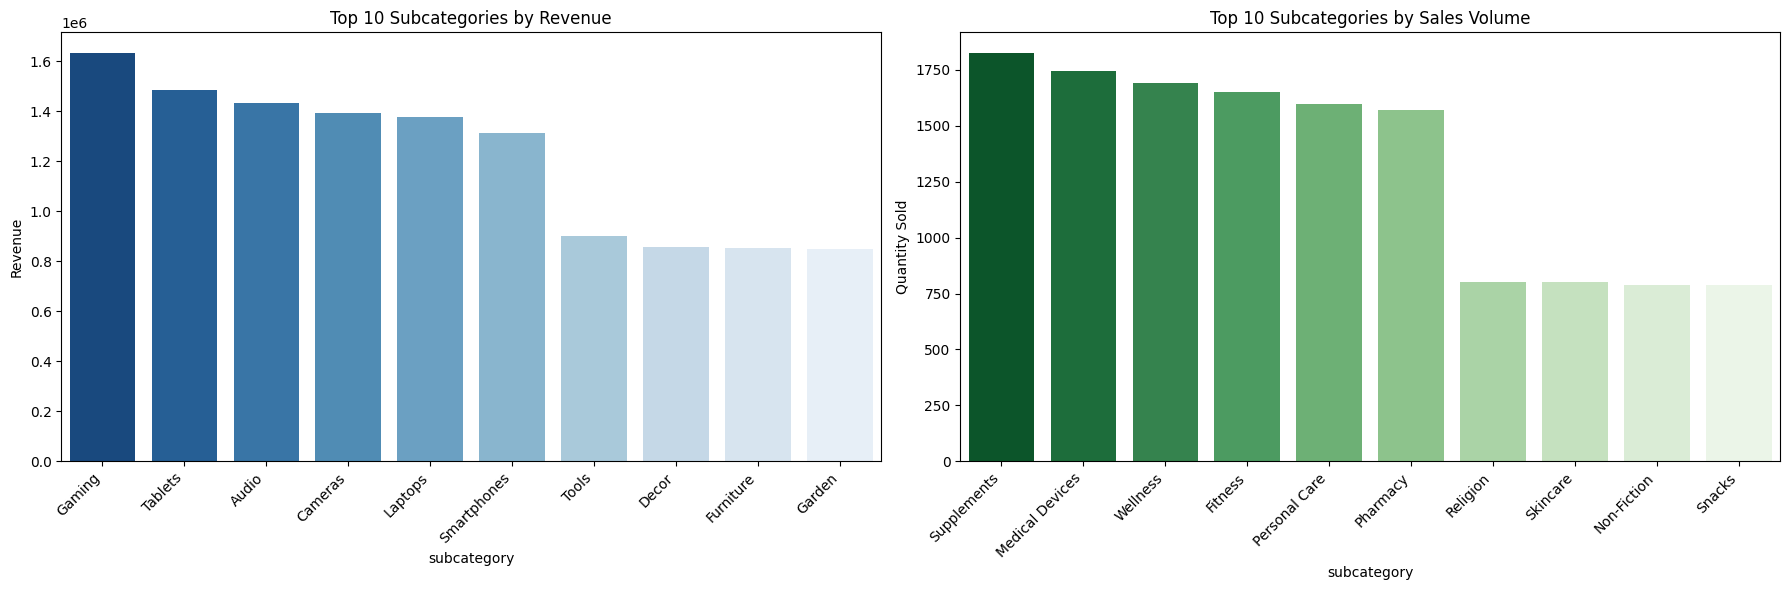

In [8]:
top_revenue = grouped_categories.sort_values('total_revenue', ascending=False).head(10)
top_quantity = grouped_categories.sort_values('total_quantity', ascending=False).head(10)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

#gaming brings the hieghest revenue, and supplements are the most purchased

sns.barplot(data=top_revenue, x='subcategory', y='total_revenue', ax=axes[0], palette='Blues_r')
axes[0].set_title("Top 10 Subcategories by Revenue")
axes[0].set_ylabel("Revenue")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

sns.barplot(data=top_quantity, x='subcategory', y='total_quantity', ax=axes[1], palette='Greens_r')
axes[1].set_title("Top 10 Subcategories by Sales Volume")
axes[1].set_ylabel("Quantity Sold")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()


gaming brings the hieghest revenue, and supplements are the most purchased

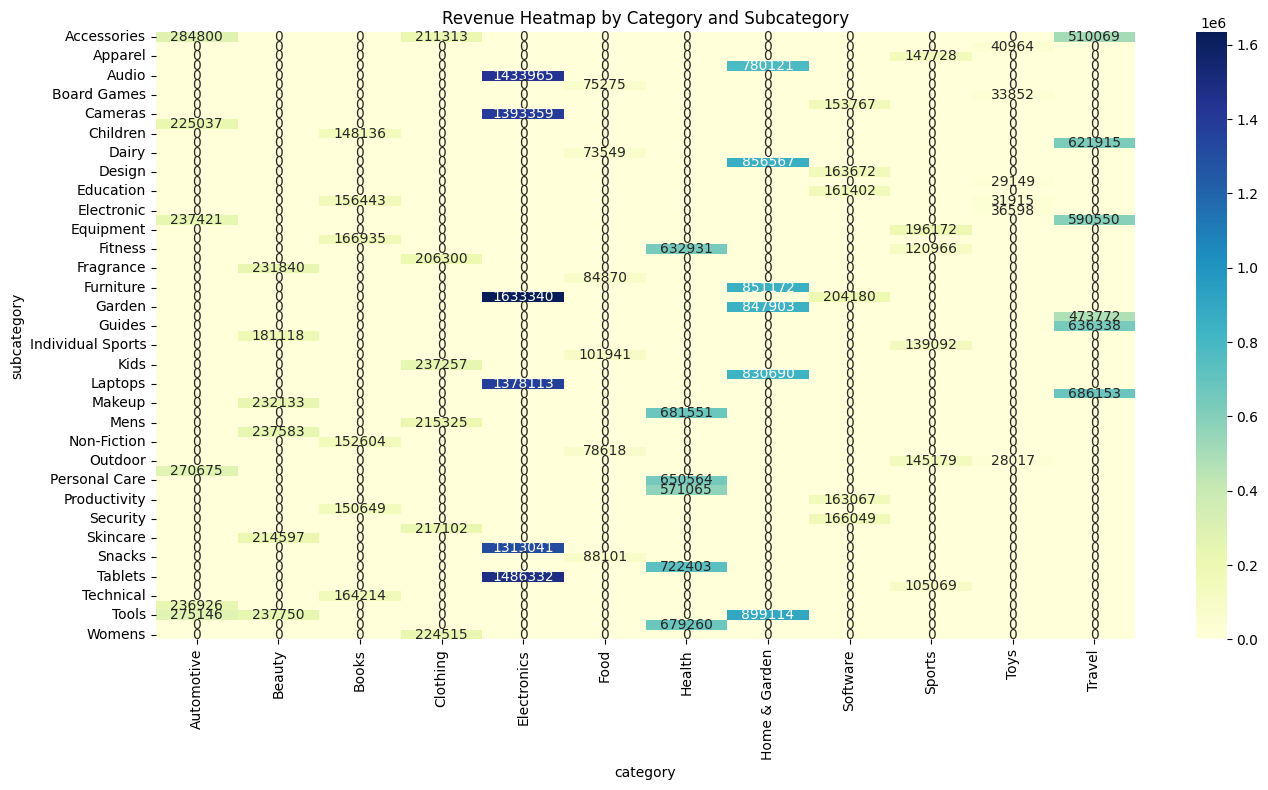

In [9]:
pivot = grouped_categories.pivot(index='subcategory', columns='category', values='total_revenue').fillna(0)

plt.figure(figsize=(14, 8))
sns.heatmap(pivot, cmap='YlGnBu', annot=True, fmt='.0f')
plt.title("Revenue Heatmap by Category and Subcategory")
plt.tight_layout()
plt.show()

***Case 6***

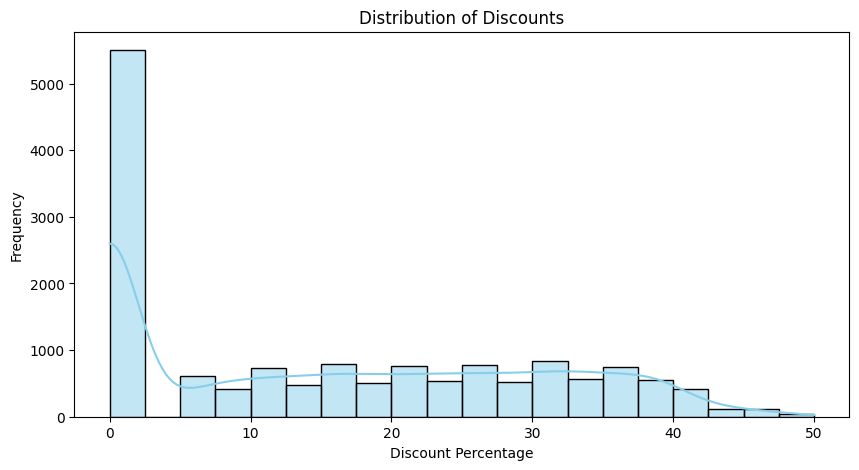

In [10]:
#visualize the discount distribution and ranges

plt.figure(figsize=(10, 5))
sns.histplot(df['discount_percent'], bins=20, kde=True, color='skyblue')
plt.title("Distribution of Discounts")
plt.xlabel("Discount Percentage")
plt.ylabel("Frequency")
plt.show()

/tmp/ipykernel_2641/1714544273.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='marketing_campaign', y='discount_percent', palette='pastel')


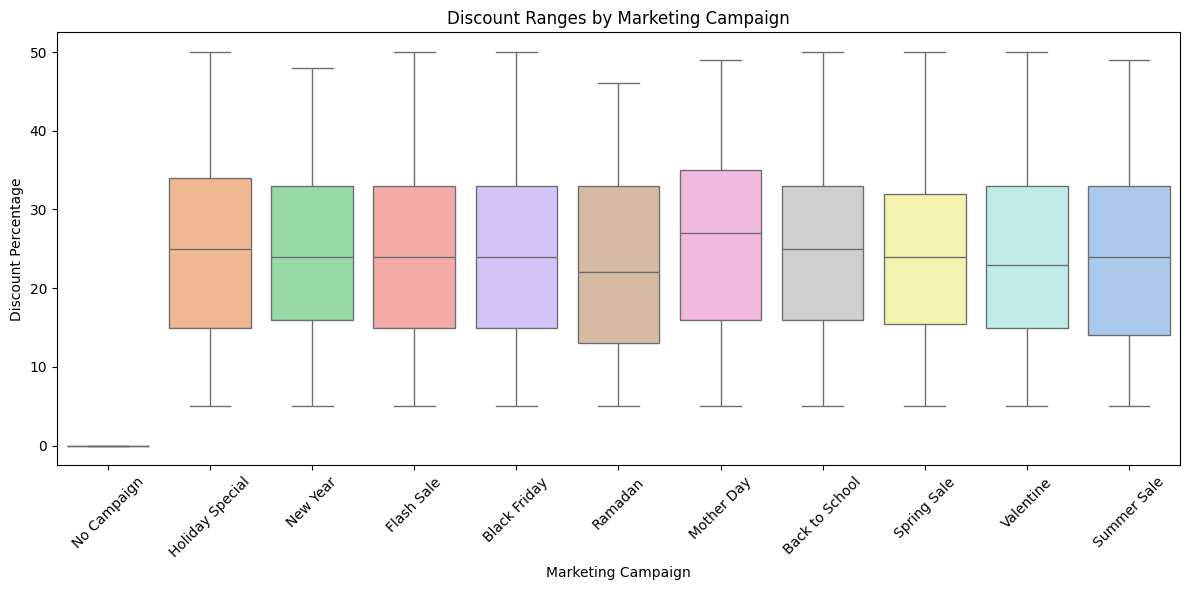

In [11]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='marketing_campaign', y='discount_percent', palette='pastel')
plt.xticks(rotation=45)
plt.title("Discount Ranges by Marketing Campaign")
plt.xlabel("Marketing Campaign")
plt.ylabel("Discount Percentage")
plt.tight_layout()
plt.show()

mother day campaign has one of the heightest discounts, and we found above that it has the highest return rate 

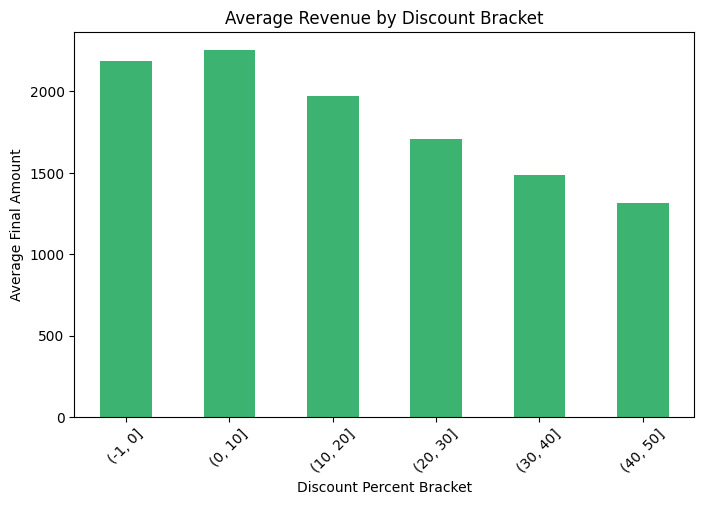

In [12]:
#divide the discount into groups of ranges:
discount_bins = pd.cut(df['discount_percent'], bins=[-1, 0, 10, 20, 30, 40, 50])
revenue_by_discount = df.groupby(discount_bins)['final_amount'].mean()

plt.figure(figsize=(8,5))
revenue_by_discount.plot(kind='bar', color='mediumseagreen')
plt.title("Average Revenue by Discount Bracket")
plt.xlabel("Discount Percent Bracket")
plt.ylabel("Average Final Amount")
plt.xticks(rotation=45)
plt.show()


we found from that :revenue drops when discount increases ,becuse products become cheaper and may cause high returns like in mother day discounts 

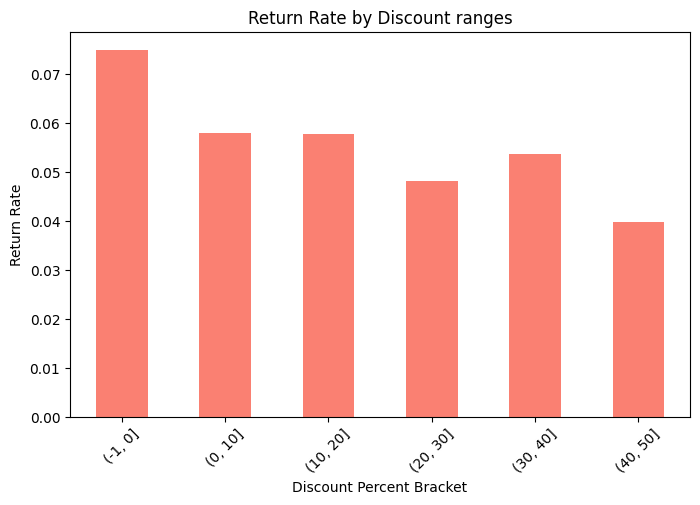

In [13]:
# returned rate by discount ranges:
return_rate_by_discount = df.groupby(discount_bins)['returned'].mean()

plt.figure(figsize=(8,5))
return_rate_by_discount.plot(kind='bar', color='salmon')
plt.title("Return Rate by Discount ranges")
plt.xlabel("Discount Percent Bracket")
plt.ylabel("Return Rate")
plt.xticks(rotation=45)
plt.show()


The analysis reveals that the highest return rates occur on full-price purchases, while increasing discount levels are not associated with increased returns. This suggests that discounts are not a driver of product returns. On the contrary, they may lead to greater customer satisfaction by aligning price expectations with product value

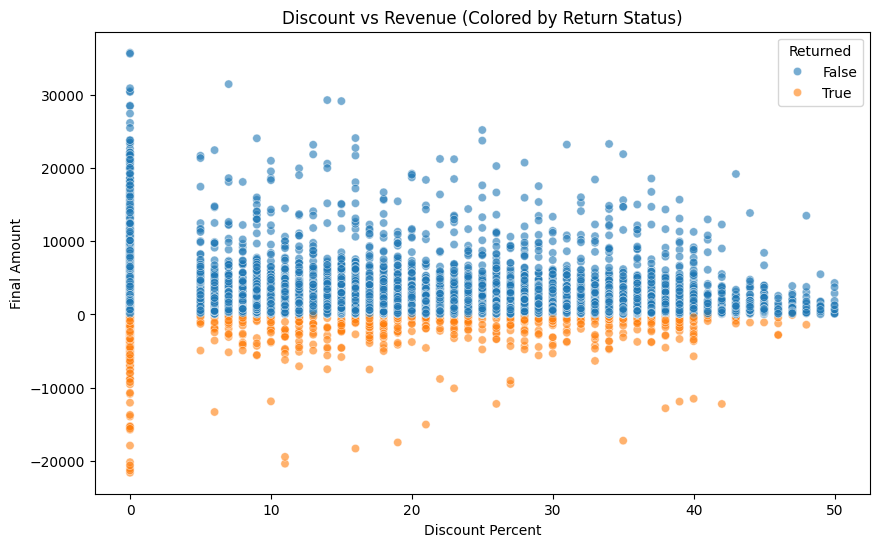

In [14]:
# analysing the revenue by discount 
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='discount_percent', y='final_amount', hue='returned', alpha=0.6)
plt.title("Discount vs Revenue (Colored by Return Status)")
plt.xlabel("Discount Percent")
plt.ylabel("Final Amount")
plt.legend(title='Returned')
plt.show()


/tmp/ipykernel_2641/2800902636.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=season_rev.index, y=season_rev.values, palette='Set3')


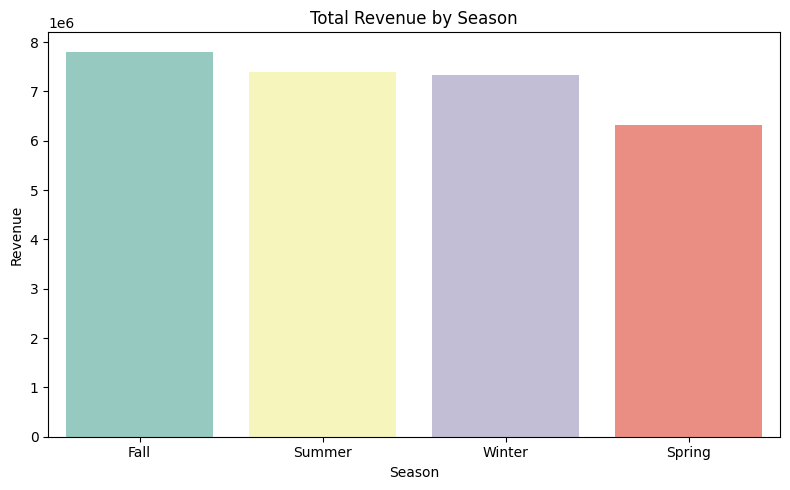

In [15]:
season_rev = df.groupby('season')['final_amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=season_rev.index, y=season_rev.values, palette='Set3')
plt.title('Total Revenue by Season')
plt.ylabel('Revenue')
plt.xlabel('Season')
plt.tight_layout()
plt.show()

fall has the height revenue and then summer and winter  as Q3 ---> summer and Q4--->fall

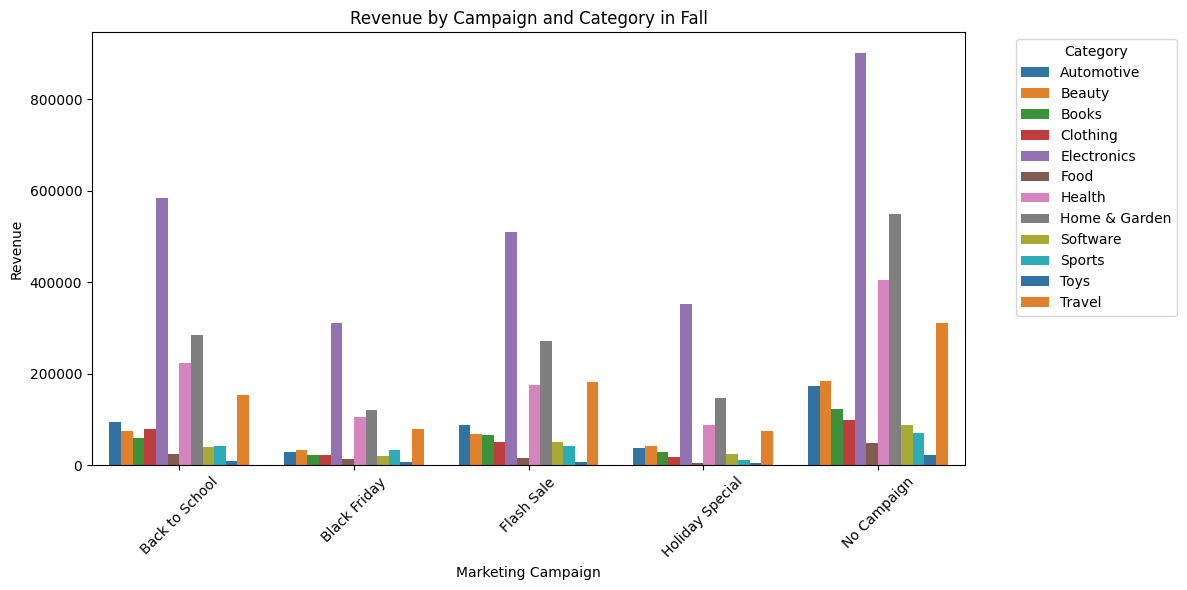

In [16]:
# analysig revenue in fall across campaignes and categories
fall_df = df[df['season'] == 'Fall']
fall_grouped = fall_df.groupby(['marketing_campaign', 'category'])['final_amount'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=fall_grouped, x='marketing_campaign', y='final_amount', hue='category', palette='tab10')
plt.title('Revenue by Campaign and Category in Fall')
plt.xlabel('Marketing Campaign')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


electronis are the most bought in fall  --->Many people buy electronics like laptops, tablets, and phones during Fall (especially around back-to-school time or Black Friday promotions)

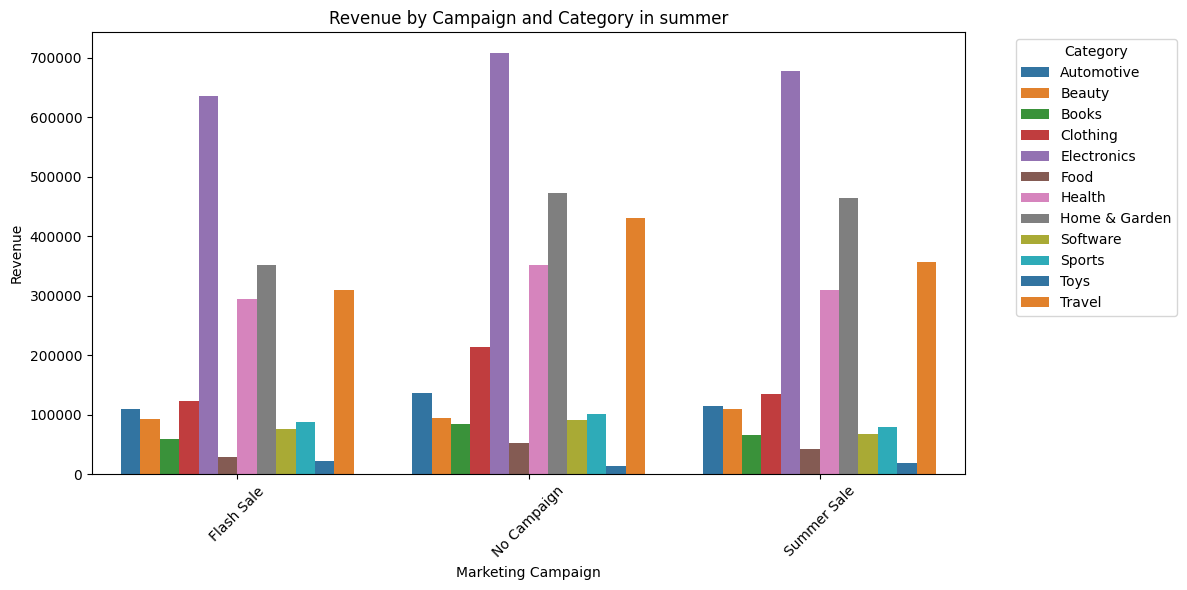

In [17]:
# analysig revenue in summer across campaignes and categories
fall_df = df[df['season'] == 'Summer']
fall_grouped = fall_df.groupby(['marketing_campaign', 'category'])['final_amount'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=fall_grouped, x='marketing_campaign', y='final_amount', hue='category', palette='tab10')
plt.title('Revenue by Campaign and Category in summer')
plt.xlabel('Marketing Campaign')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

electronis are the most bought in summer too  --> In Summer, people might buy electronics like cameras, headphones, smartwatches, and portable gadgets for travel and leisure.

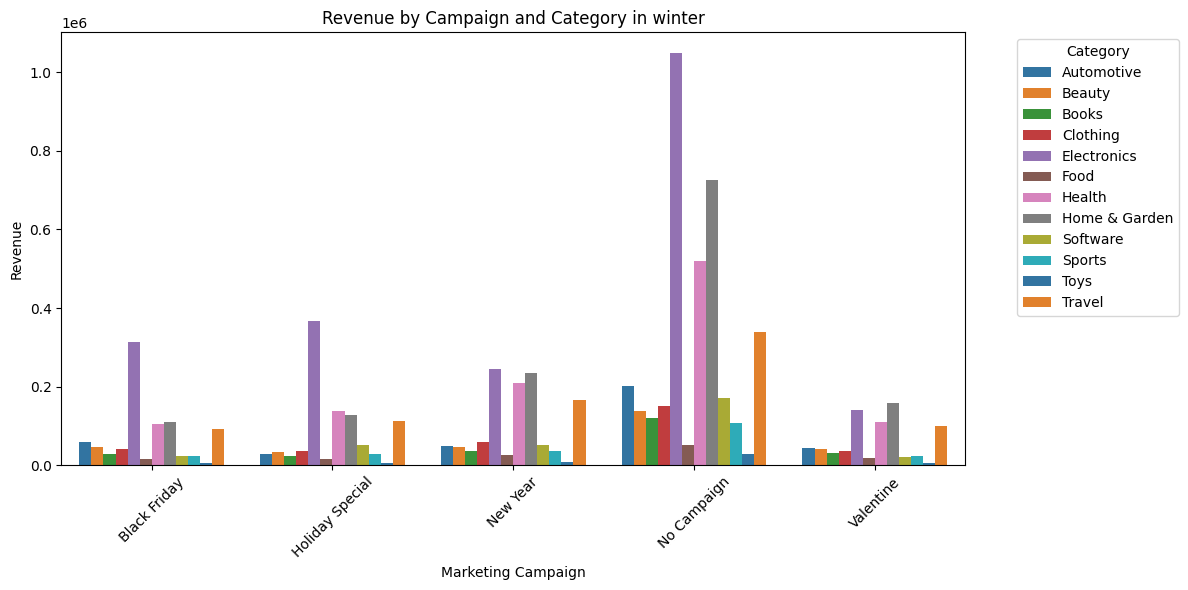

In [18]:
# analysig revenue in winter across campaignes and categories
fall_df = df[df['season'] == 'Winter']
fall_grouped = fall_df.groupby(['marketing_campaign', 'category'])['final_amount'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=fall_grouped, x='marketing_campaign', y='final_amount', hue='category', palette='tab10')
plt.title('Revenue by Campaign and Category in winter')
plt.xlabel('Marketing Campaign')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2641/2742792786.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=electronics_season, x='season', y='final_amount', palette='coolwarm')


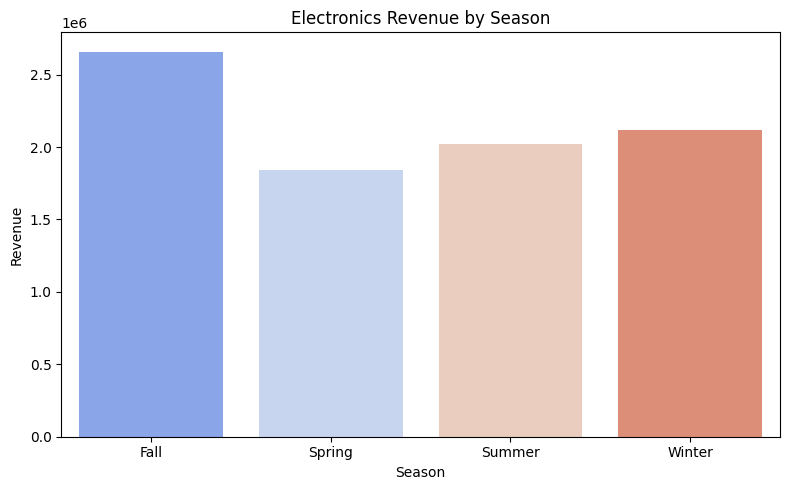

In [ ]:
# analyse electronics purchase in all seasons
season_cat_rev = df.groupby(['season', 'category'])['final_amount'].sum().reset_index()

electronics_season = season_cat_rev[season_cat_rev['category'] == 'Electronics']

plt.figure(figsize=(8, 5))
sns.barplot(data=electronics_season, x='season', y='final_amount', palette='coolwarm')
plt.title('Electronics Revenue by Season')
plt.ylabel('Revenue')
plt.xlabel('Season')
plt.tight_layout()
plt.show()


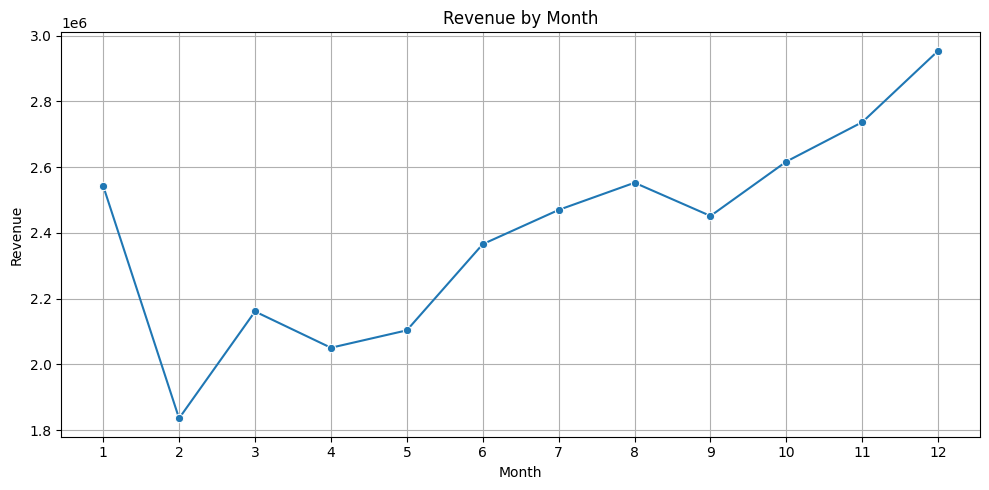

In [20]:
month_rev = df.groupby('month')['final_amount'].sum()

plt.figure(figsize=(10, 5))
sns.lineplot(x=month_rev.index, y=month_rev.values, marker='o')
plt.title('Revenue by Month')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(range(1, 13))
plt.grid(True)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2641/572294452.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=quarter_rev.index, y=quarter_rev.values, palette='pastel')


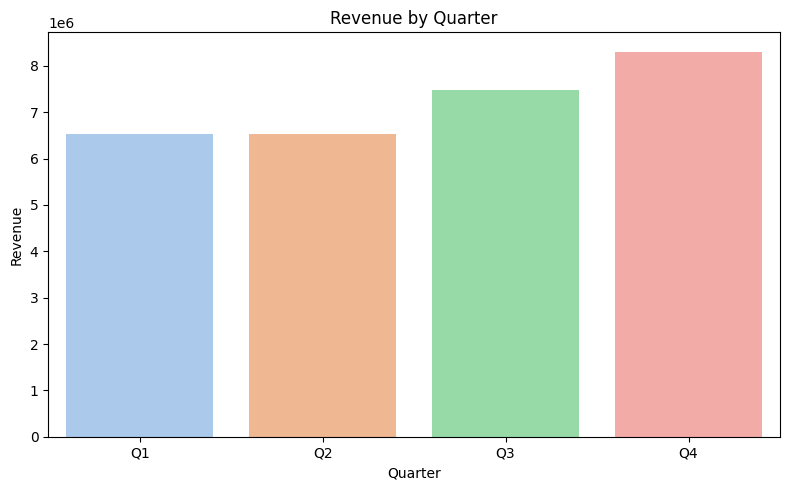

In [21]:
quarter_rev = df.groupby('quarter')['final_amount'].sum()

plt.figure(figsize=(8, 5))
sns.barplot(x=quarter_rev.index, y=quarter_rev.values, palette='pastel')
plt.title('Revenue by Quarter')
plt.ylabel('Revenue')
plt.xlabel('Quarter')
plt.tight_layout()
plt.show()


/tmp/ipykernel_2641/759823882.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='season', y='final_amount', hue='category', estimator='sum', ci=None)


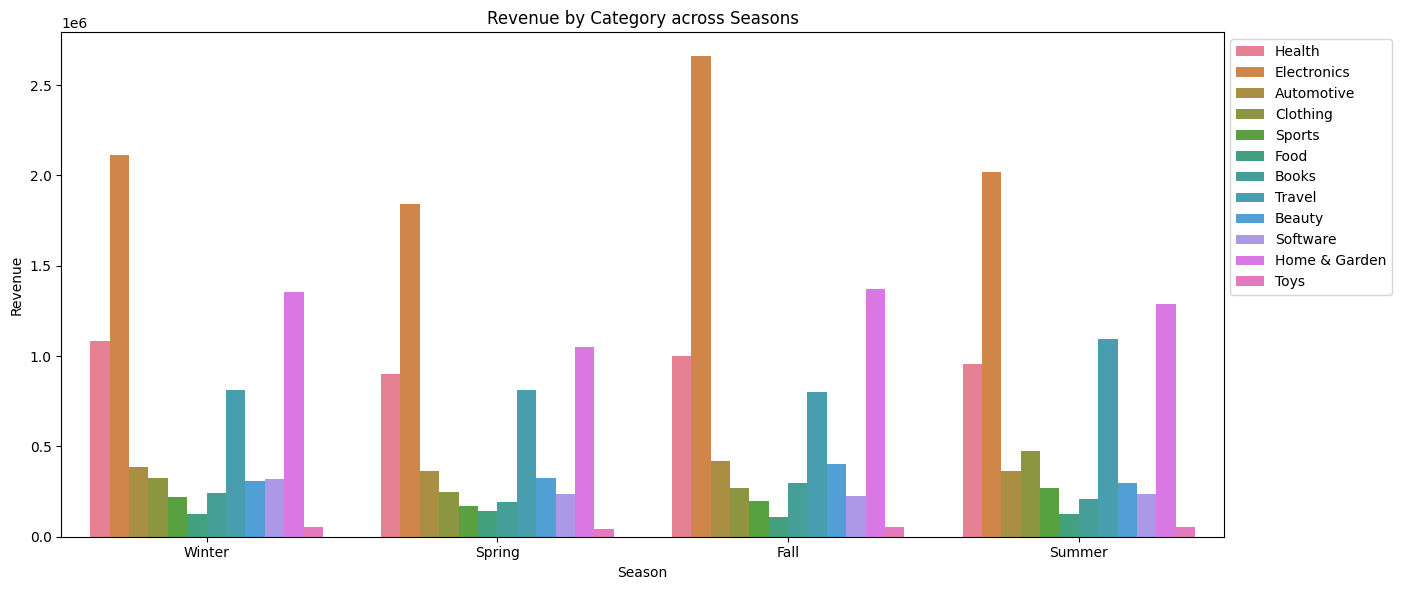

In [22]:
#revenue by season across categories
plt.figure(figsize=(14, 6))
sns.barplot(data=df, x='season', y='final_amount', hue='category', estimator='sum', ci=None)
plt.title('Revenue by Category across Seasons')
plt.ylabel('Revenue')
plt.xlabel('Season')
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.show()


/tmp/ipykernel_2641/308452864.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df, x='month', y='final_amount', hue='category', estimator='sum', ci=None, marker='o')


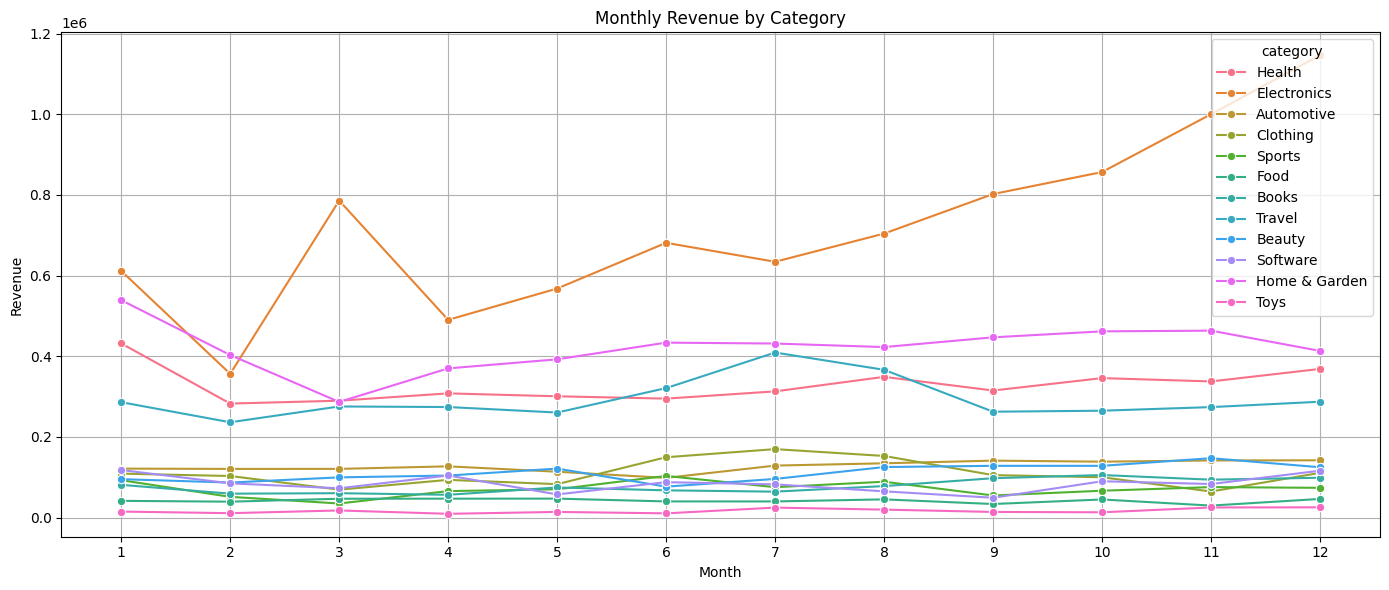

In [23]:
# monthly revenue across categories
plt.figure(figsize=(14, 6))
sns.lineplot(data=df, x='month', y='final_amount', hue='category', estimator='sum', ci=None, marker='o')
plt.title('Monthly Revenue by Category')
plt.ylabel('Revenue')
plt.xlabel('Month')
plt.xticks(range(1, 13))
plt.grid(True)
plt.tight_layout()
plt.show()


/tmp/ipykernel_2641/704476537.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='quarter', y='final_amount', hue='category', estimator='sum', ci=None)


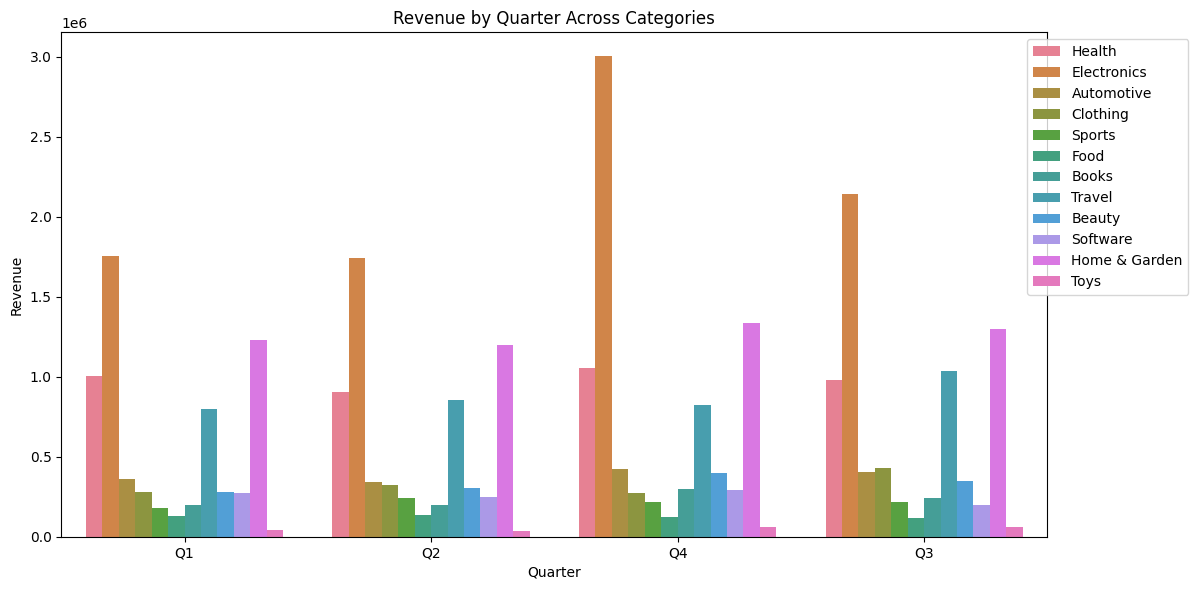

In [24]:
#quarter revenue across categories
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='quarter', y='final_amount', hue='category', estimator='sum', ci=None)
plt.title('Revenue by Quarter Across Categories')
plt.xlabel('Quarter')
plt.ylabel('Revenue')
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.show()


**case 8**

In [47]:
#analysinf the returned revenue by region, city anf campaign
print(returned_df.head())
region_returned_revenue = returned_df.groupby('region')['final_amount'].sum().sort_values(ascending=False)
city_returned_revenue = df.groupby('city')['final_amount'].sum().sort_values(ascending=False)
campaign_returned_revenue = df.groupby('marketing_campaign')['final_amount'].sum().sort_values(ascending=False)

     order_id        date customer_id  age  gender   city         region  \
1   ORD010001  2023-05-13   CUST01941   63  Female  Tanta          Delta   
4   ORD010004  2022-01-16   CUST02347   38  Female   Giza  Greater Cairo   
10  ORD010010  2023-04-12   CUST00264   55    Male  Sohag    Upper Egypt   
39  ORD010039  2023-05-23   CUST02466   32    Male   Giza  Greater Cairo   
62  ORD010062  2023-12-22   CUST02647   40    Male  Cairo  Greater Cairo   

    income       category  subcategory  price  quantity  discount_percent  \
1     7235         Health     Pharmacy    482         8                 0   
4     9345    Electronics  Smartphones   3148         3                33   
10    8876           Food      Organic    134         6                12   
39    8902  Home & Garden    Furniture   1273         1                43   
62   12812       Software     Security    517         4                 0   

    final_amount     payment_method customer_segment marketing_campaign  \
1    

/tmp/ipykernel_2641/1850223845.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_returned_revenue.values, y=region_returned_revenue.index, ax=axes[0], palette='Reds_r')
/tmp/ipykernel_2641/1850223845.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cities.values, y=top_cities.index, ax=axes[1], palette='Oranges_r')
/tmp/ipykernel_2641/1850223845.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=campaign_returned_revenue.values, y=campaign_returned_revenue.index, ax=axes[2], palette='Purples_r')


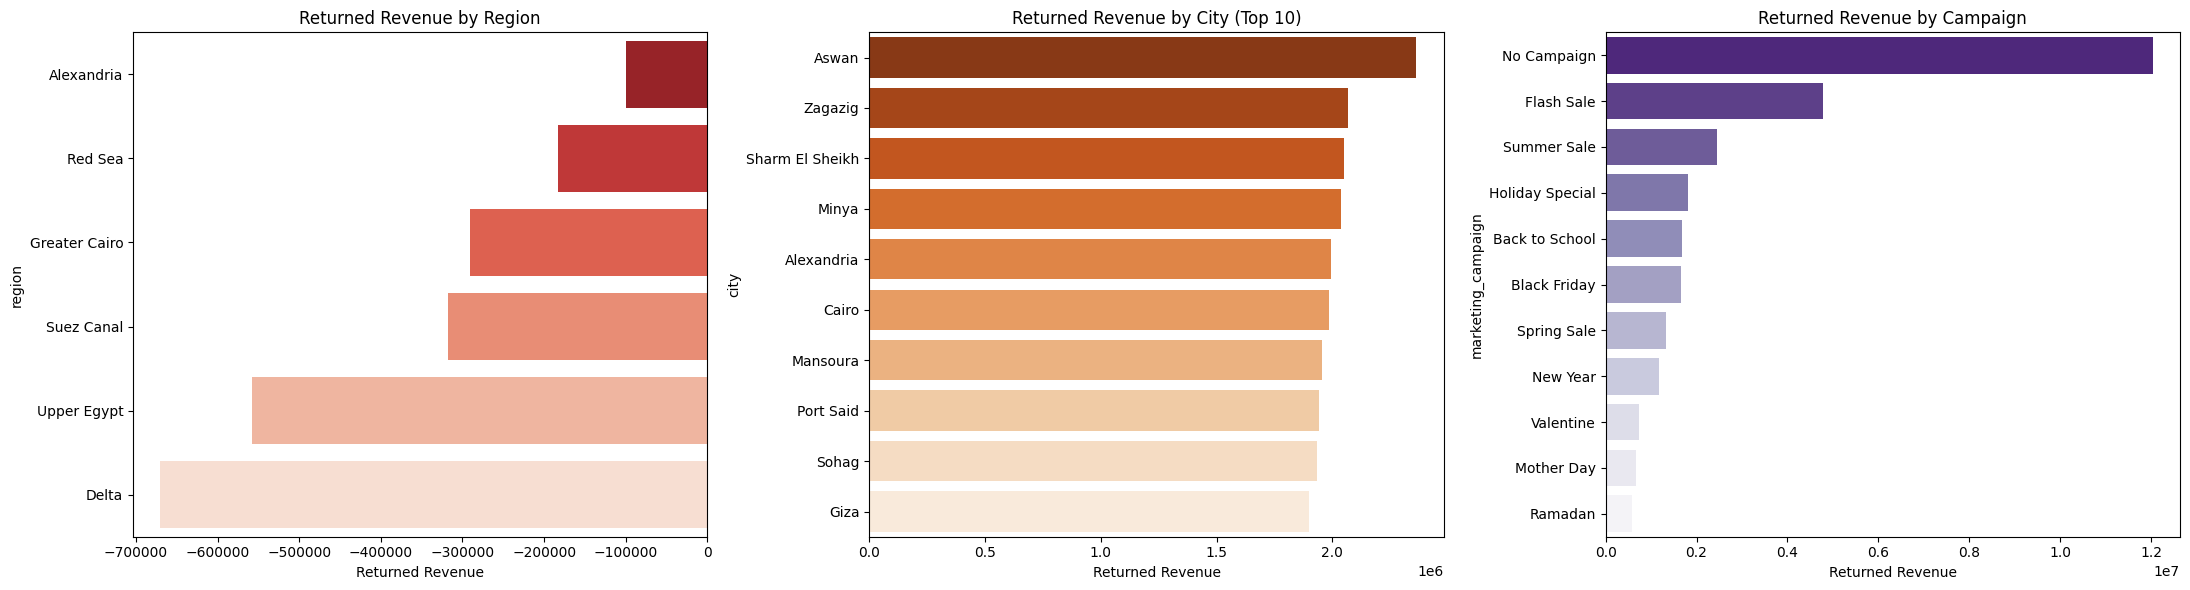

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.barplot(x=region_returned_revenue.values, y=region_returned_revenue.index, ax=axes[0], palette='Reds_r')
axes[0].set_title("Returned Revenue by Region")
axes[0].set_xlabel("Returned Revenue")

top_cities = city_returned_revenue.head(10)  # maybe just top 10 to avoid long graph
sns.barplot(x=top_cities.values, y=top_cities.index, ax=axes[1], palette='Oranges_r')
axes[1].set_title("Returned Revenue by City (Top 10)")
axes[1].set_xlabel("Returned Revenue")

sns.barplot(x=campaign_returned_revenue.values, y=campaign_returned_revenue.index, ax=axes[2], palette='Purples_r')
axes[2].set_title("Returned Revenue by Campaign")
axes[2].set_xlabel("Returned Revenue")

plt.tight_layout()
plt.show()


delta is the most egion with return 

/tmp/ipykernel_2641/4117791915.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


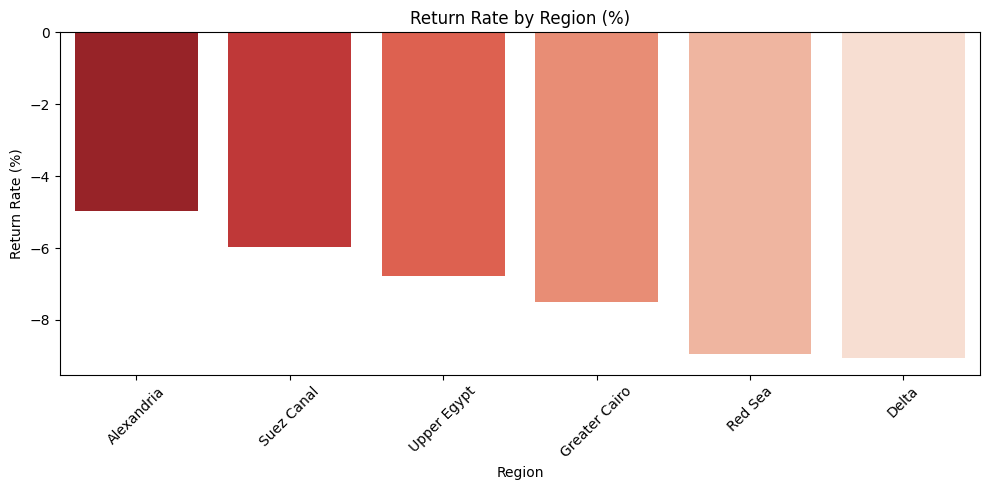

In [49]:
#analysing delta by the return rate 
total_revenue_by_region = df.groupby('region')['final_amount'].sum()
returned_revenue_by_region = returned_df.groupby('region')['final_amount'].sum()

return_rate_by_region = (returned_revenue_by_region / total_revenue_by_region) * 100
return_rate_by_region = return_rate_by_region.sort_values(ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(
    x=return_rate_by_region.index,
    y=return_rate_by_region.values,
    palette='Reds_r'
)

plt.title('Return Rate by Region (%)')
plt.xlabel('Region')
plt.ylabel('Return Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

we checked that delta doew not have higher sales over all but higher return rate

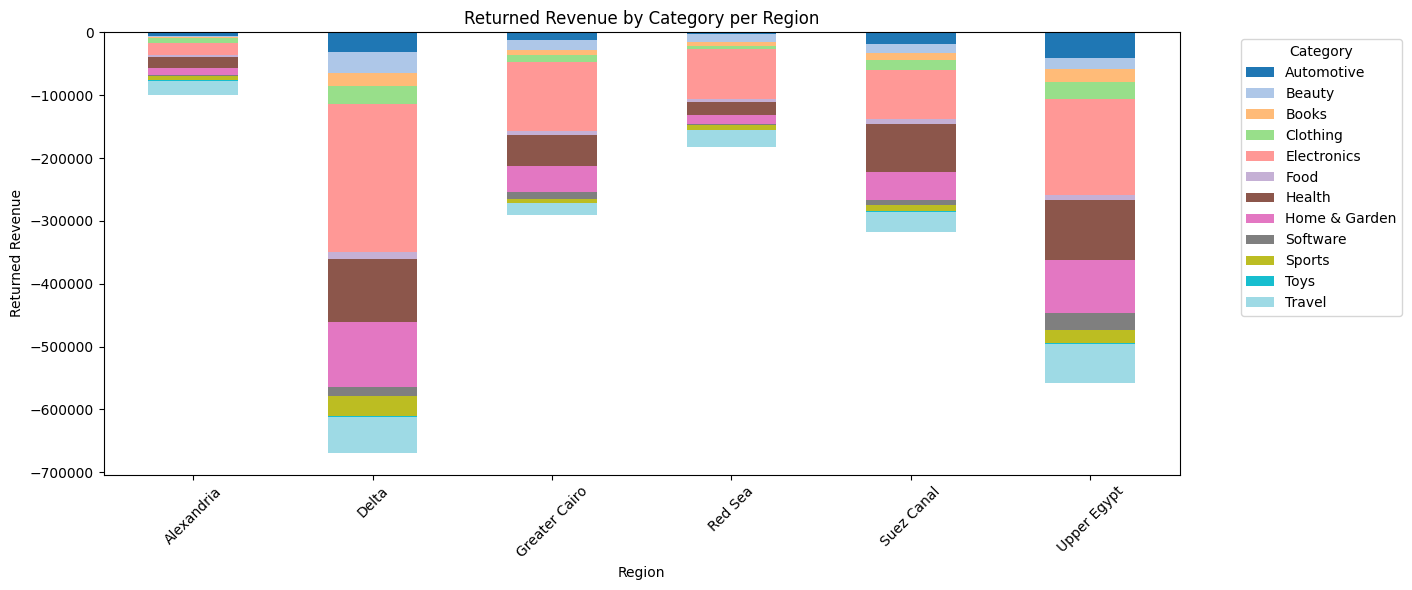

In [50]:
#see what are the most returned categories
returned_category_region = returned_df.groupby(['region', 'category'])['final_amount'].sum().unstack().fillna(0)
returned_category_region.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab20')
plt.title("Returned Revenue by Category per Region")
plt.xlabel("Region")
plt.ylabel("Returned Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

electronics are the most returned in delta and upper egypt